In [1]:
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 133.6 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2025.3.0 which is incompatible.


### 1. Imports and Config

In [2]:
import json
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

# ONLY this line differs from Step 4 - everything else is identical,
# so any difference in results is attributable to the checkpoint, not setup.
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128
LABELS = ["negative", "neutral", "positive"]
PROCESSED_DIR = "processed"
MODEL_OUT_DIR = "bert-finetuned"   # separate folder, doesn't overwrite FinBERT's
SEED = 42

torch.manual_seed(SEED)

### 2. Load Data and Tokenize

In [3]:
train_df = pd.read_csv(f"{PROCESSED_DIR}/train.csv")
val_df = pd.read_csv(f"{PROCESSED_DIR}/val.csv")
test_df = pd.read_csv(f"{PROCESSED_DIR}/test.csv")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_dataframe(df):
    ds = Dataset.from_pandas(df[["sentence", "label"]], preserve_index=False)
    return ds.map(
        lambda batch: tokenizer(batch["sentence"], truncation=True, max_length=MAX_LENGTH),
        batched=True,
        remove_columns=["sentence"],
    )

train_ds = tokenize_dataframe(train_df)
val_ds = tokenize_dataframe(val_df)
test_ds = tokenize_dataframe(test_df)
print(train_ds, val_ds, test_ds)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/3868 [00:00<?, ? examples/s]

Map:   0%|          | 0/484 [00:00<?, ? examples/s]

Map:   0%|          | 0/484 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3868
}) Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 484
}) Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 484
})


### 3. Model, Metrics, Training Setup

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, y_true = eval_pred
    y_pred = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    }

training_args = TrainingArguments(
    output_dir="bert_checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=0.1,
    logging_steps=50,
    seed=SEED,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [7]:
trainer.train() #968 epochs

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.458459,0.406403,0.845041,0.812729
2,0.324790,0.346141,0.876033,0.856622
3,0.149683,0.438747,0.873967,0.865310
4,0.056059,0.477865,0.865702,0.857308


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=968, training_loss=0.3133214515102796, metrics={'train_runtime': 316.2148, 'train_samples_per_second': 48.929, 'train_steps_per_second': 3.061, 'total_flos': 470111732404776.0, 'train_loss': 0.3133214515102796, 'epoch': 4.0})

### 4. Test Evaluation

In [8]:
predictions = trainer.predict(test_ds)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

test_accuracy = accuracy_score(y_true, y_pred)
test_macro_f1 = f1_score(y_true, y_pred, average="macro")

print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Macro F1:  {test_macro_f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=LABELS, digits=3))

Test Accuracy:  0.8698
Test Macro F1:  0.8549

              precision    recall  f1-score   support

    negative      0.839     0.852     0.846        61
     neutral      0.887     0.906     0.897       287
    positive      0.845     0.801     0.823       136

    accuracy                          0.870       484
   macro avg      0.857     0.853     0.855       484
weighted avg      0.869     0.870     0.869       484



### 5. Confusion Matrix

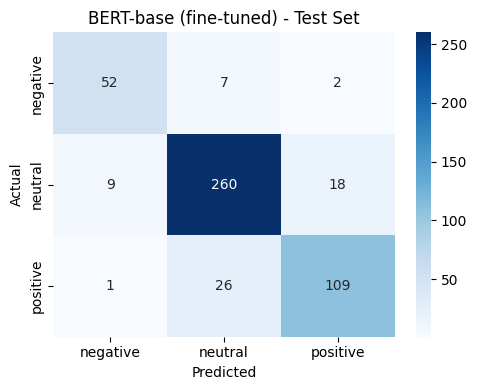

Saved: bert_confusion_matrix.png, bert_test_metrics.json, bert_test_predictions.csv


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BERT-base (fine-tuned) - Test Set")
plt.tight_layout()
plt.savefig("bert_confusion_matrix.png", dpi=150)
plt.show()

results = {"model": "BERT-base (fine-tuned)", "test_accuracy": float(test_accuracy), "test_macro_f1": float(test_macro_f1)}
with open("bert_test_metrics.json", "w") as f:
    json.dump(results, f, indent=2)

bert_df_with_preds = test_df.copy()
bert_df_with_preds["predicted_label"] = y_pred
bert_df_with_preds["predicted_label_name"] = [LABELS[i] for i in y_pred]
bert_df_with_preds["is_correct"] = bert_df_with_preds["label"] == bert_df_with_preds["predicted_label"]
bert_df_with_preds.to_csv("bert_test_predictions.csv", index=False)

print("Saved: bert_confusion_matrix.png, bert_test_metrics.json, bert_test_predictions.csv")